In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib.pyplot as plt

In [2]:
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold


In [3]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 1
x_scale = 10000.0
y_scale = 0.0
z_scale = 10000.0 # Depth

In [4]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 100
R_max = 1000
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = x_scale * np.random.rand(N_chamber)
y_nodes = y_scale * np.random.rand(N_chamber)
z_nodes = z_scale * np.random.rand(N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=None,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [5]:
list_nodes

[Chamber at      (5488.1350392732475, 0.0, 6027.633760716439)
 Mass (kg)       4.78420e+12
 Energy (MJ)     5.78388e+12
 Volume (m^3)    2284307728.5553279
 Temperature (K) 1200.0000000
 Pressure (MPa)  -168.67374530
 Density (kg)    2094.374623
 Depth (km)      6.027634]

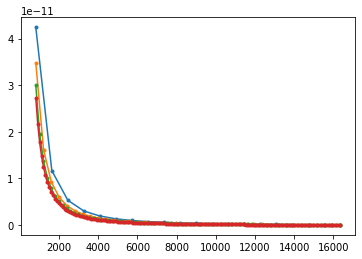

In [6]:
Nr_range = [20, 40, 80, 160]

for Nr in Nr_range:
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=Nr,
                                    dpdx_crit=1e3,
                                    dpdx_threshold_scale=1e1,
                                    R_outer_ratio=20,)
  # Extraction
  node = global_sys.nodes[0]
  q0 = global_sys.q0
  # Column mapping mass to displacement
  H_col = np.array(node.H[:,2*global_sys.Nr].todense()).ravel()
  k = node.k.ravel()
  plt.plot(node.r_mesh, H_col + 0*k, '.-')
  H_col.flatten()


Linear displacement $u$ is given by
$$
u = Hq + k,
$$
with Jacobian
$$
\frac{\partial u}{\partial q} = H
$$
where the $j$-th column of $u$ gives the dependence of $u$ on $q_j$.

For the pure elastic problem, the exact solution for the exterior of a spherical inclusion of radius $R_0$ is
$$
u = U R_0^2 r^{-2},
$$
where
$$
U = \frac{R_0}{3} \left( \frac{m}{m_0} - 1 \right) \frac{K_\mathrm{f}}{K_\mathrm{f} + (4G / 3)}
$$
is dependent on the injected mass $\Delta m / m_0 = m/m_0 - 1$ and the fluid bulk modulus $K_\mathrm{f}$.

Note that the interior elastic problem is in a uniform volumetric stress/strain state, with no deviatoric stress/strain.

In the limit of a highly compressible fluid, $K_\mathrm{f} = \varepsilon \downarrow 0$, and
$$
U \approx \frac{R_0}{4G} \left( \frac{m}{m_0} - 1 \right) K_\mathrm{f},
$$
which can be compared to the displacement solution using a pressure boundary condition $p (r= R_0) = p_0$. In the latter case, the characteristic displacement is
$$
U_{p_0} = \frac{R_0}{4G} p_0;
$$
the relative pressure $p_0$ can be identified with the quantity $K_\mathrm{f} \Delta m / m_0 \approx K_\mathrm{f} \Delta V / V_0$.

In the following, we compare the dependence of the boundary displacement on mass. That is, we compare $\partial u / \partial m$ at $r = R_0$ and $t = 0$ with the analytic formula
$$
\frac{\partial u}{\partial m} = \frac{R_0}{3 m_0} \frac{K_\mathrm{f}}{K_\mathrm{f} + (4G / 3)},
$$
where $G$ is the crustal shear modulus.

In [9]:
u_R_coefficient(K_crust)

-3.0

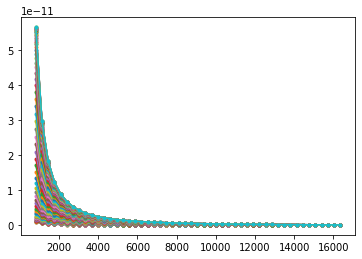

In [73]:
K_f_range = np.geomspace(1e-2, 1e2, 60) * K_crust
dRdm_range = 0 * K_f_range

for i, K_f in enumerate(K_f_range):
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=1e3,
                                    dpdx_threshold_scale=1e1,
                                    R_outer_ratio=20,)
  # Extraction
  node = global_sys.nodes[0]
  q0 = global_sys.q0
  # Column mapping mass to displacement
  H_col = np.array(node.H[:,2*global_sys.Nr].todense()).ravel()
  k = node.k.ravel()
  plt.plot(node.r_mesh, H_col, '.-')
  
  dRdm_range[i] = H_col.flatten()[0]


In [74]:
def dUdm_analytic(K_f):
  return node.R0 / (3 * node.m0) * K_f / (K_f + (4.0/3.0) * G_crust)

Text(0, 0.5, '$(\\partial U / \\partial m) ~/~ (R_0 / m_0)$')

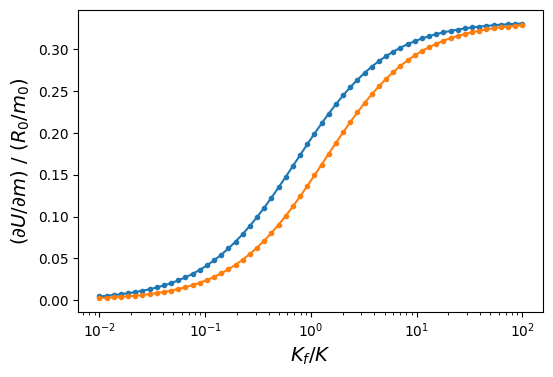

In [75]:
plt.figure(figsize=(6,4) , dpi=100)
plt.semilogx(K_f_range / (K_crust + 0*4*G_crust/3), dRdm_range / (node.R0 / node.m0), '.-')
plt.semilogx(K_f_range / (K_crust + 0*4*G_crust/3), dUdm_analytic(K_f_range) / (node.R0 / node.m0), '.-')
plt.xlabel("$K_f / K$", fontsize=14)
plt.ylabel("$(\partial U / \partial m) ~/~ (R_0 / m_0)$", fontsize=14)


K_f / K = 1.0


C:\Users\Fredric\AppData\Local\Temp\ipykernel_58584\1742266616.py:42: RuntimeWarning: divide by zero encountered in true_divide
  lambda N: (node.r_mesh[-1] - node.r_mesh[0]) / N))


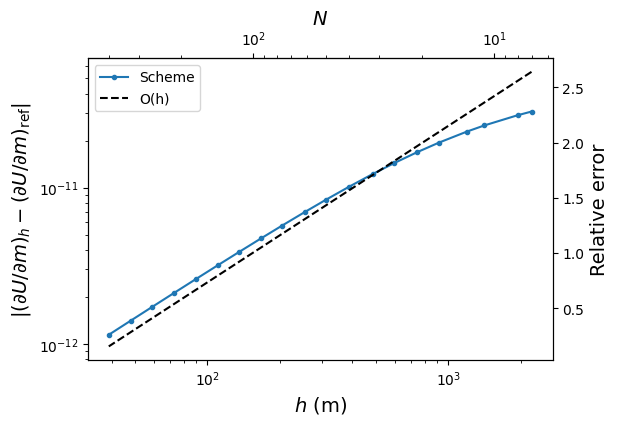

In [86]:
''' Grid convergence at K_f == K '''

Nr_range = np.geomspace(8, 400, 20).astype(int)
dr_range = 0.0 * Nr_range
dRdm_range2 = 0.0 * Nr_range
K_f = K_crust

for i, Nr in enumerate(Nr_range):
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=Nr,
                                    dpdx_crit=1e3,
                                    dpdx_threshold_scale=1e1,
                                    R_outer_ratio=20,)
  # Extraction
  node = global_sys.nodes[0]
  q0 = global_sys.q0
  # Column mapping mass to displacement
  H_col = np.array(node.H[:,2*global_sys.Nr].todense()).ravel()
  k = node.k.ravel()
  dRdm_range2[i] = H_col.flatten()[0]
  dr_range[i] = node.dx


ref_soln = dUdm_analytic(K_crust)

plt.figure(figsize=(6,4) , dpi=100)
plt.loglog(dr_range, np.abs(dRdm_range2 - ref_soln), '.-')
plt.loglog(dr_range, dr_range / dr_range[0] * dRdm_range2[0], 'k--')
plt.legend(["Scheme", "O(h)"])
plt.xlabel("$h$ (m)", fontsize=14)
plt.ylabel("$|(\partial U / \partial m)_h - (\partial U / \partial m)_\mathrm{ref}|$", fontsize=14)

ax1 = plt.gca()
ax2x = ax1.twinx()
ymin, ymax = ax1.get_ylim()
ax2x.set_ylim(ymin / ref_soln, ymax / ref_soln)
ax2x.set_ylabel('Relative error', fontsize=14)

ax2y = ax1.secondary_xaxis('top', functions=(
  lambda h: (node.r_mesh[-1] - node.r_mesh[0]) / h,
  lambda N: (node.r_mesh[-1] - node.r_mesh[0]) / N))
ax2y.set_xlabel('$N$', fontsize=14)

print(f"K_f / K = {K_f/K_crust:.2}")


#### Meeting Notes 1/10
* Regional stresses on dikes / edges
* Thermomechanical coupling of nearby nodes
* EOS of magma, and related: degassing and volatile fluxing
* Crystallization, thermal deletion of chambers and spawning


* Moving nodes as a result of mantle convection
* Melt influx spatial / temporal distribution as an input to system, and timing of eruption as output
    * Viscoelastic relaxation as tempo control
* To couple to the geodynamic code, need an effective cell property (viscosity and modulus, heat source or sink)
* To couple from the geodynamic code, can use continuum stresses, temperatures and pull apart the chamber network as the crust thins
    * Also possible is the re-thickening as temperature effects change in the crust, chambers freeze up

* Geodynamic code: use with a subgrid scale model needs the effective shear viscosity and elastic modulus

* Dike freezing
* LIPs: large volume chambers necessary, and may be larger than the 1 km geodynamic cell size and thus resolvable (at least marginally)

* See also: Manoo + papers